## LSTM Training

### Load the saved sequences

In [1]:
import json

with open("../data/sequences.json", "r") as f:
    all_sequences = json.load(f)

print(len(all_sequences))

2850


In [2]:
import pandas as pd

df = pd.read_csv("../data/spotify_tracks.csv")

In [3]:
mood_features = [
    "energy",
    "valence",
    "danceability",
    "acousticness",
    "tempo"
]

In [4]:
import numpy as np

X = []
y = []

for seq in all_sequences:

    feature_sequence = (
        df.loc[seq, mood_features]
        .values
    )

    X.append(feature_sequence[:-1])
    y.append(feature_sequence[-1])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(2850, 7, 5)
(2850, 5)


### Train/Test Split

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42
)

In [7]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.15,
    random_state=42
)

In [8]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (2058, 7, 5)
Validation: (364, 7, 5)
Test: (428, 7, 5)


In [9]:
np.savez_compressed(
    "../data/train_val_test_split.npz",
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test
)

In [10]:
data = np.load("../data/train_val_test_split.npz")

X_train = data["X_train"]
y_train = data["y_train"]

X_val = data["X_val"]
y_val = data["y_val"]

X_test = data["X_test"]
y_test = data["y_test"]

In [11]:
sample_x = X_train[0]
sample_y = y_train[0]

print("Input Sequence:")
print(sample_x)

print("\nTarget:")
print(sample_y)

Input Sequence:
[[1.3500e-01 5.3500e-02 1.4500e-01 9.7800e-01 7.7975e+01]
 [1.3500e-01 5.3500e-02 1.4500e-01 9.7800e-01 7.7975e+01]
 [1.3500e-01 5.3500e-02 1.4500e-01 9.7800e-01 7.7975e+01]
 [1.3500e-01 5.3500e-02 1.4500e-01 9.7800e-01 7.7975e+01]
 [1.1900e-01 3.5100e-02 1.6800e-01 9.4100e-01 6.4537e+01]
 [6.5100e-02 3.8000e-02 1.8200e-01 9.4200e-01 6.0812e+01]
 [3.2500e-02 2.8400e-02 1.7100e-01 9.7000e-01 7.0821e+01]]

Target:
[2.5600e-03 3.3400e-02 1.7900e-01 9.3300e-01 6.6138e+01]


### Model Training

In [12]:
print(X_train.shape)
print(y_train.shape)

(2058, 7, 5)
(2058, 5)


In [13]:
sample_x = X_train[0]
sample_y = y_train[0]

sample_x

array([[1.3500e-01, 5.3500e-02, 1.4500e-01, 9.7800e-01, 7.7975e+01],
       [1.3500e-01, 5.3500e-02, 1.4500e-01, 9.7800e-01, 7.7975e+01],
       [1.3500e-01, 5.3500e-02, 1.4500e-01, 9.7800e-01, 7.7975e+01],
       [1.3500e-01, 5.3500e-02, 1.4500e-01, 9.7800e-01, 7.7975e+01],
       [1.1900e-01, 3.5100e-02, 1.6800e-01, 9.4100e-01, 6.4537e+01],
       [6.5100e-02, 3.8000e-02, 1.8200e-01, 9.4200e-01, 6.0812e+01],
       [3.2500e-02, 2.8400e-02, 1.7100e-01, 9.7000e-01, 7.0821e+01]])

In [15]:
%pip install tensorflow

  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
  Using cached ml_dtypes-0.5.4-cp313-cp313-win_amd64.whl.metadata (9.2 kB)
  Using cached charset_normalizer-3.4.7-cp313-cp313-win_amd64.whl.metadata (41 kB)
  Using cached urllib3-2.7.0-py3-none-any.whl.metadata (6.9 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached markdown_it_py-4.2.0-py3-none-any.whl.metadata (7.4 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   ---------------------------------------- 1.0/351.2 MB 3.3 MB/s eta 0:01:45
   ---------------------------------------- 3.9/351.2 MB 6.7 MB/s eta 0:00:52
    --


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping
)

from sklearn.metrics import (
    mean_absolute_error
)

### Define Model
Requirements:

- 2 LSTM layers
- Dropout
- Regression output
- MSE loss

In [19]:
n_timesteps = X_train.shape[1]
n_features = X_train.shape[2]

model = Sequential([
    
    LSTM(
        64,
        return_sequences=True,
        input_shape=(n_timesteps, n_features)
    ),
    
    Dropout(0.3),
    
    LSTM(32),
    
    Dropout(0.3),
    
    Dense(
        16,
        activation='relu'
    ),
    
    Dense(n_features)
])

### Compile Model

In [20]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [21]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 7, 64)          │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,949 (120.89 KB)

 Trainable params: 30,949 (120.89 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

### Train Model

In [24]:
history = model.fit(
    X_train,
    y_train,
    
    validation_data=(
        X_val,
        y_val
    ),
    
    epochs=100,
    
    batch_size=32,
    
    callbacks=[
        early_stop
    ],
    
    verbose=1
)

Epoch 1/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 2960.8406 - mae: 24.3758 - val_loss: 2720.6995 - val_mae: 23.7955
Epoch 2/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2553.0205 - mae: 23.1602 - val_loss: 2262.1084 - val_mae: 21.5486
Epoch 3/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2040.0685 - mae: 20.1828 - val_loss: 1689.2643 - val_mae: 17.8385
Epoch 4/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1442.7692 - mae: 16.4608 - val_loss: 1106.1257 - val_mae: 14.1128
Epoch 5/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 893.3954 - mae: 12.5306 - val_loss: 637.2785 - val_mae: 10.2450
Epoch 6/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 518.0146 - mae: 9.0112 - val_loss: 346.0160 - val_mae: 7.1000
Epoch 7/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 297.2506 - mae: 6.5528 - val_loss: 204.7507 - val_mae: 5.3374
Epoch 8/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 215.4500 - mae: 5.5275 - val_loss: 153.0833 - val_mae: 4.6375
Epoch 9/100
65

### Plot Training Curves

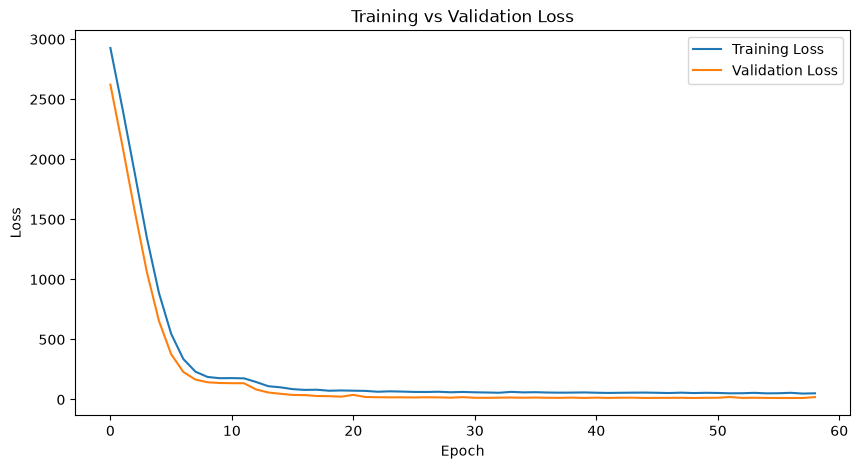

In [23]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training vs Validation Loss"
)

plt.legend()

plt.show()

### Evaluate on Test Set

In [25]:
test_loss, test_mae = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test MAE:", test_mae)

Test Loss: 12.788788795471191
Test MAE: 1.3513087034225464


### Generate Predictions

In [26]:
y_pred = model.predict(X_test)

print(y_pred.shape)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
(428, 5)


### Compute MAE Per Feature

In [27]:
mood_features = [
    "energy",
    "valence",
    "danceability",
    "acousticness",
    "tempo"
]

In [28]:
feature_mae = {}

for i, feature in enumerate(
    mood_features
):

    mae = mean_absolute_error(
        y_test[:, i],
        y_pred[:, i]
    )

    feature_mae[feature] = mae

print("Feature-wise MAE:")
for feature, mae in feature_mae.items():
    print(f"{feature}: {mae}")

Feature-wise MAE:
energy: 0.2190785334529966
valence: 0.23105199446076544
danceability: 0.14381642789116528
acousticness: 0.2880784732929494
tempo: 5.874518434613664


### Compare Actual vs Predicted

In [29]:
sample_idx = 0

comparison = pd.DataFrame({

    "Feature": mood_features,

    "Actual":
        y_test[sample_idx],

    "Predicted":
        y_pred[sample_idx]
})

comparison

,Feature,Actual,Predicted
0,energy,0.897000,0.818053
1,valence,0.802000,0.598136
2,danceability,0.466000,0.672776
3,acousticness,0.000206,0.209383
4,tempo,159.988000,163.141769


### Save Model

In [30]:
model.save(
    "../models/lstm_next_track.keras"
)